# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


PROYEK Membangun Sistem Machine Learning (MSML) – ADVANCED
Prediksi Customer Churn Menggunakan Dataset Churn Modelling

Dataset:
Kaggle: https://www.kaggle.com/datasets/osama12bin/churn-model-dataset/data

File yang digunakan: Churn_Modelling.csv

Tujuan proyek digunakan untuk:

Memprediksi apakah customer akan churn atau tidak.
Membuat sistem machine learning end-to-end.
Melakukan preprocessing.
Training dan hyperparameter tuning.
Monitoring model.
Logging inference.
Visualisasi Grafana.
Alerting system.
Deployment sederhana.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [125]:
# ======================================================
# IMPORT LIBRARY
# ======================================================

# manipulasi data
import pandas as pd
import numpy as np

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# split data
from sklearn.model_selection import train_test_split

# model machine learning
from sklearn.ensemble import RandomForestClassifier

# evaluasi model
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix
)

# ignore warning
import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimport')

Semua library berhasil diimport


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [126]:
# =========================================================
# DATA LOADING
# =========================================================

df = pd.read_csv(
    '../BC-Churn_raw/Churn_Modelling.csv'
)

print("="*50)
print("DATASET PREVIEW")
print("="*50)

display(df.head(20))

print("="*50)
print("DATASET SHAPE")
print("="*50)

print(df.shape)

DATASET PREVIEW


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


DATASET SHAPE
(10000, 14)


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [127]:
# =========================================================
# DATA INFORMATION
# =========================================================

print("="*50)
print("DATASET INFO")
print("="*50)

df.info(20)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [111]:
# ======================================================
# CEK MISSING VALUE
# ======================================================

missing_values = df.isnull().sum()

print(missing_values)

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [112]:
# ======================================================
# CEK DUPLICATE DATA
# ======================================================

duplicates = df.duplicated().sum()

print('Jumlah duplicate data:')
print(duplicates)

Jumlah duplicate data:
0


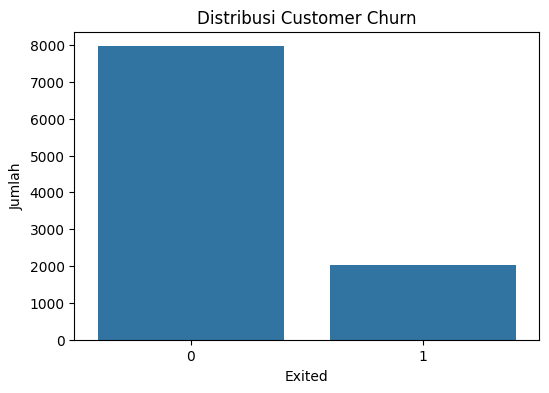

In [113]:
# ======================================================
# DISTRIBUSI TARGET
# ======================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='Exited',
    data=df
)

plt.title('Distribusi Customer Churn')
plt.xlabel('Exited')
plt.ylabel('Jumlah')

plt.show()

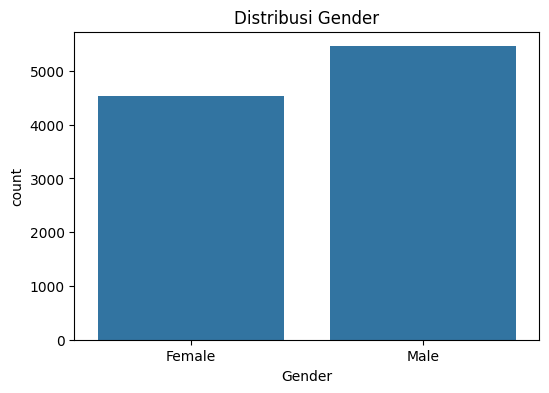

In [114]:
# ======================================================
# DISTRIBUSI GENDER
# ======================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df
)

plt.title('Distribusi Gender')
plt.show()

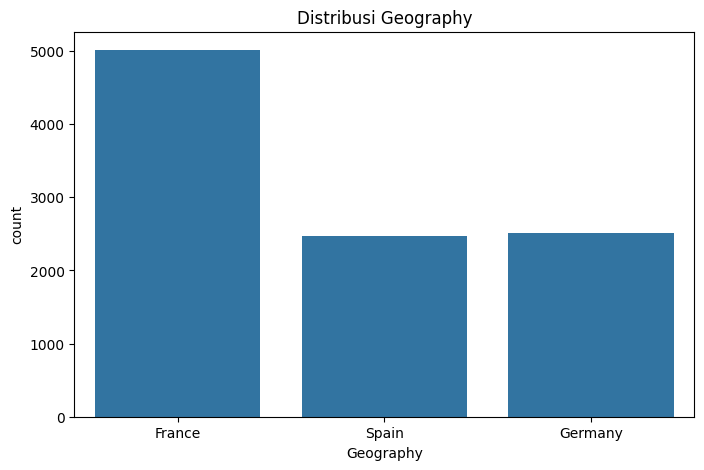

In [115]:
# ======================================================
# DISTRIBUSI GEOGRAPHY
# ======================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Geography',
    data=df
)

plt.title('Distribusi Geography')
plt.show()

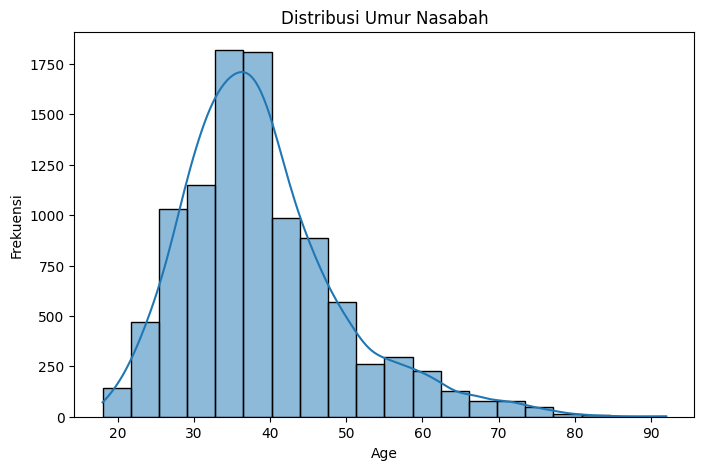

In [116]:
# ======================================================
# DISTRIBUSI AGE
# ======================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title('Distribusi Umur Nasabah')
plt.xlabel('Age')
plt.ylabel('Frekuensi')

plt.show()

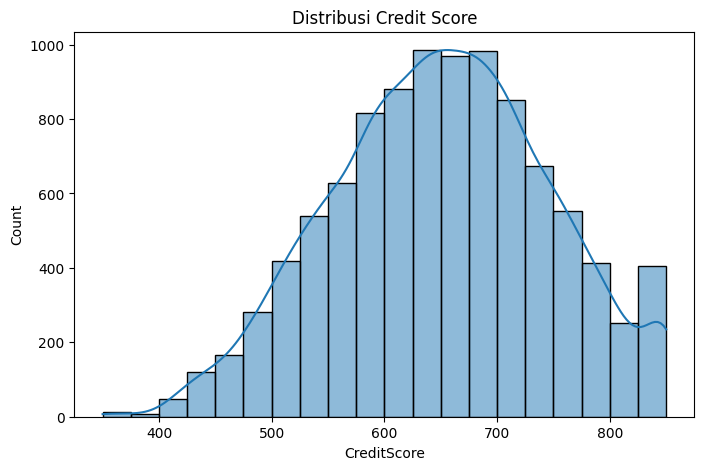

In [91]:
# ======================================================
# DISTRIBUSI CREDIT SCORE
# ======================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['CreditScore'],
    bins=20,
    kde=True
)

plt.title('Distribusi Credit Score')
plt.show()

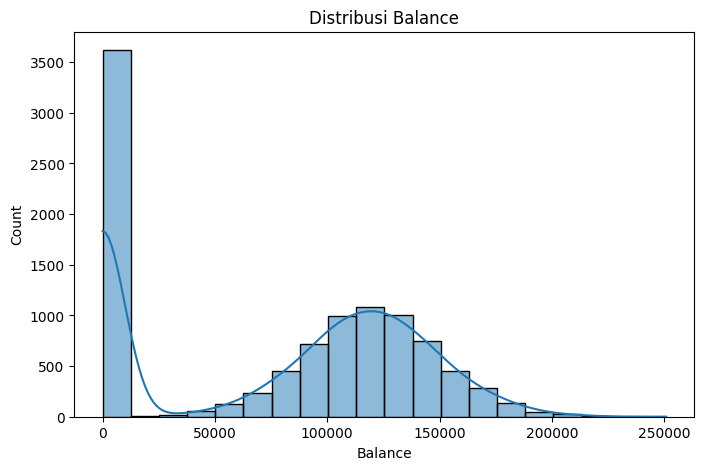

In [92]:
# ======================================================
# DISTRIBUSI BALANCE
# ======================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Balance'],
    bins=20,
    kde=True
)

plt.title('Distribusi Balance')
plt.show()

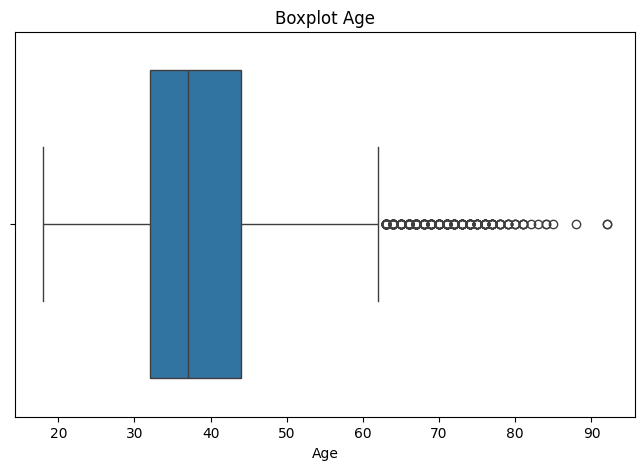

In [93]:
# ======================================================
# BOXPLOT AGE
# ======================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Age']
)

plt.title('Boxplot Age')
plt.show()

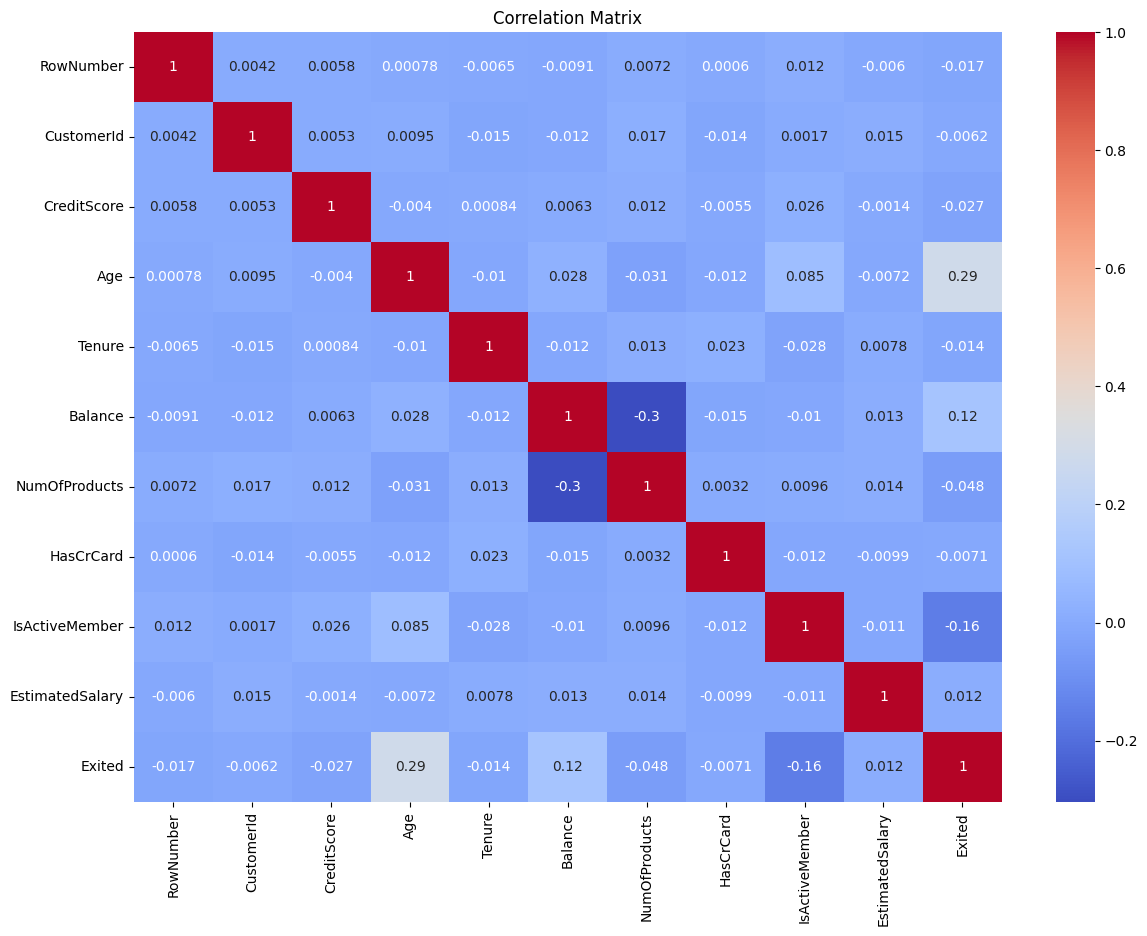

In [117]:
# ======================================================
# CORRELATION MATRIX
# ======================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [128]:
# ======================================================
# DROP COLUMN
# ======================================================

df = df.drop(
    ['RowNumber', 'CustomerId', 'Surname'], 
    axis=1
)
df.head(20)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [ ]:
# ======================================================
# LABEL ENCODING
# ======================================================

le = LabelEncoder()

df.loc[:, 'Gender'] = le.fit_transform(df['Gender'])

# ======================================================
# ONE HOT ENCODING
# ======================================================

df = pd.get_dummies(
    df, 
    columns=['Geography'], 
    drop_first=False, 
    dtype=int
)

df.head(20)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1
5,645,1,44,8,113755.78,2,1,0,149756.71,1,0,0,1
6,822,1,50,7,0.00,2,1,1,10062.80,0,1,0,0
7,376,0,29,4,115046.74,4,1,0,119346.88,1,0,1,0
8,501,1,44,4,142051.07,2,0,1,74940.50,0,1,0,0
9,684,1,27,2,134603.88,1,1,1,71725.73,0,1,0,0


In [130]:
# ======================================================
# SPLIT FEATURE DAN TARGET
# ======================================================

X = df.drop('Exited', axis=1)
y = df['Exited']

print(X.shape)
print(y.shape)

(10000, 12)
(10000,)


In [131]:
# ======================================================
# TRAIN TEST SPLIT
# ======================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (8000, 12)
X_test : (2000, 12)


In [132]:
# ======================================================
# FEATURE SCALING
# ======================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Feature scaling berhasil')

Feature scaling berhasil


In [133]:
# ======================================================
# TRAINING RANDOM FOREST
# ======================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

print('Training Random Forest selesai')

Training Random Forest selesai


In [134]:
# ======================================================
# PREDIKSI RANDOM FOREST
# ======================================================

rf_pred = rf_model.predict(X_test)

In [135]:
# ======================================================
# EVALUASI RANDOM FOREST
# ======================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print('Accuracy :', rf_accuracy)

Accuracy : 0.8675


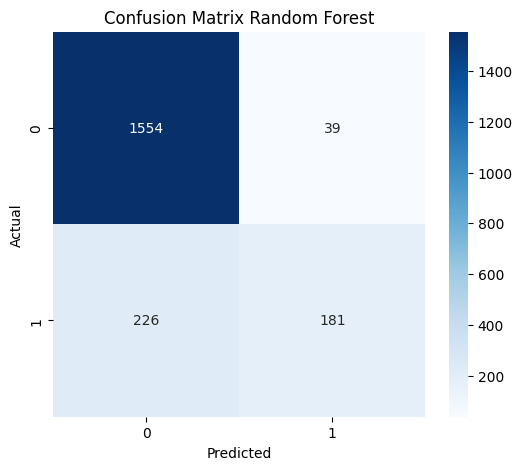

In [136]:
# ======================================================
# CONFUSION MATRIX RANDOM FOREST
# ======================================================

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()